# Model Training and Evaluation

This notebook handles model training, hyperparameter tuning, and evaluation for the sentiment analysis task.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sklearn.metrics import classification_report, confusion_matrix

# Add src to path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

# Import our modules
from data_loader import DataLoader
from feature_engineering import FeatureEngineer
from train import ModelTrainer
from evaluate import ModelEvaluator
from utils import setup_logging, format_time

# Setup
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Setup logging
setup_logging("INFO")

print("Libraries imported successfully!")

[nltk_data] Downloading package wordnet to C:\Users\MSI BRAVO
[nltk_data]     15\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Libraries imported successfully!


## 1. Load Prepared Data

In [2]:
# Load the prepared data splits
try:
    train_df = pd.read_csv('../data/train.csv')
    val_df = pd.read_csv('../data/val.csv')
    test_df = pd.read_csv('../data/test.csv')
    print("Data splits loaded successfully!")
except FileNotFoundError:
    print("Data splits not found. Loading and preparing data...")
    # Load and prepare data if splits don't exist
    loader = DataLoader('../data/IMDB Dataset.csv')
    df = loader.load_data()
    df_clean = loader.clean_data()
    train_df, val_df, test_df = loader.split_data()
    loader.save_splits(train_df, val_df, test_df)

print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

# Display sentiment distribution
print("\nSentiment distribution:")
for split_name, split_df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    sentiment_dist = split_df['sentiment'].value_counts()
    print(f"{split_name}: {sentiment_dist.to_dict()}")

Data splits loaded successfully!
Training set: 34706 samples
Validation set: 4959 samples
Test set: 9917 samples

Sentiment distribution:
Train: {'positive': 17418, 'negative': 17288}
Validation: {'positive': 2489, 'negative': 2470}
Test: {'positive': 4977, 'negative': 4940}


## 2. Feature Engineering

In [3]:
# Initialize feature engineer
feature_engineer = FeatureEngineer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    remove_stopwords=True,
    use_lemmatization=True
)

print("Feature engineering parameters:")
print(f"  Max features: {feature_engineer.max_features}")
print(f"  N-gram range: {feature_engineer.ngram_range}")
print(f"  Min document frequency: {feature_engineer.min_df}")
print(f"  Max document frequency: {feature_engineer.max_df}")
print(f"  Remove stopwords: {feature_engineer.remove_stopwords}")
print(f"  Use lemmatization: {feature_engineer.use_lemmatization}")

Feature engineering parameters:
  Max features: 10000
  N-gram range: (1, 2)
  Min document frequency: 5
  Max document frequency: 0.9
  Remove stopwords: True
  Use lemmatization: True


In [16]:
# Fit and transform training data
print("Processing training data...")
start_time = time.time()

X_train, y_train = feature_engineer.fit_transform_features(
    train_df['review'], train_df['sentiment']
)

train_time = time.time() - start_time
print(f"Training data processed in {format_time(train_time)}")
print(f"Training features shape: {X_train.shape}")
print(f"Vocabulary size: {feature_engineer.get_vocabulary_size()}")

# Transform validation and test data
print("\nProcessing validation data...")
X_val, y_val = feature_engineer.transform_features(val_df['review'], val_df['sentiment'])
print(f"Validation features shape: {X_val.shape}")

print("\nProcessing test data...")
X_test, y_test = feature_engineer.transform_features(test_df['review'], test_df['sentiment'])
print(f"Test features shape: {X_test.shape}")

Processing training data...


INFO:preprocessing:Processed 1000/34706 texts
INFO:preprocessing:Processed 2000/34706 texts
INFO:preprocessing:Processed 3000/34706 texts
INFO:preprocessing:Processed 4000/34706 texts
INFO:preprocessing:Processed 5000/34706 texts
INFO:preprocessing:Processed 6000/34706 texts
INFO:preprocessing:Processed 7000/34706 texts
INFO:preprocessing:Processed 8000/34706 texts
INFO:preprocessing:Processed 9000/34706 texts
INFO:preprocessing:Processed 10000/34706 texts
INFO:preprocessing:Processed 11000/34706 texts
INFO:preprocessing:Processed 12000/34706 texts
INFO:preprocessing:Processed 13000/34706 texts
INFO:preprocessing:Processed 14000/34706 texts
INFO:preprocessing:Processed 15000/34706 texts
INFO:preprocessing:Processed 16000/34706 texts
INFO:preprocessing:Processed 17000/34706 texts
INFO:preprocessing:Processed 18000/34706 texts
INFO:preprocessing:Processed 19000/34706 texts
INFO:preprocessing:Processed 20000/34706 texts
INFO:preprocessing:Processed 21000/34706 texts
INFO:preprocessing:Pro

Training data processed in 1.30 minutes
Training features shape: (34706, 10000)
Vocabulary size: 10000

Processing validation data...


INFO:preprocessing:Processed 1000/4959 texts
INFO:preprocessing:Processed 2000/4959 texts
INFO:preprocessing:Processed 3000/4959 texts
INFO:preprocessing:Processed 4000/4959 texts
INFO:preprocessing:Batch preprocessing completed for 4959 texts
INFO:feature_engineering:Features transformed. Shape: (4959, 10000)


Validation features shape: (4959, 10000)

Processing test data...


INFO:preprocessing:Processed 1000/9917 texts
INFO:preprocessing:Processed 2000/9917 texts
INFO:preprocessing:Processed 3000/9917 texts
INFO:preprocessing:Processed 4000/9917 texts
INFO:preprocessing:Processed 5000/9917 texts
INFO:preprocessing:Processed 6000/9917 texts
INFO:preprocessing:Processed 7000/9917 texts
INFO:preprocessing:Processed 8000/9917 texts
INFO:preprocessing:Processed 9000/9917 texts
INFO:preprocessing:Batch preprocessing completed for 9917 texts
INFO:feature_engineering:Features transformed. Shape: (9917, 10000)


Test features shape: (9917, 10000)


In [17]:
# Display feature engineering information
feature_info = feature_engineer.get_feature_importance_info()
print("Feature Engineering Information:")
for key, value in feature_info.items():
    print(f"  {key}: {value}")

# Display sample feature names
feature_names = feature_engineer.get_feature_names()
print(f"\nSample feature names (first 20):")
for i, feature in enumerate(feature_names[:20]):
    print(f"  {i+1:2d}. {feature}")

Feature Engineering Information:
  vocabulary_size: 10000
  max_features: 10000
  ngram_range: (1, 2)
  min_df: 5
  max_df: 0.9
  remove_stopwords: True
  use_lemmatization: True
  num_classes: 2
  classes: ['negative', 'positive']

Sample feature names (first 20):
   1. aaron
   2. abandon
   3. abandoned
   4. abbott
   5. abc
   6. ability
   7. able
   8. able get
   9. able see
  10. aboard
  11. abomination
  12. abortion
  13. abound
  14. abraham
  15. abroad
  16. abrupt
  17. abruptly
  18. absence
  19. absent
  20. absolute


## 3. Model Training

In [18]:
# Initialize model trainer
trainer = ModelTrainer(random_state=42)

print("Available models:")
for model_name in trainer.model_configs.keys():
    print(f"  - {model_name}")

print("\nHyperparameter grids:")
for model_name, config in trainer.model_configs.items():
    print(f"\n{model_name}:")
    for param, values in config['params'].items():
        print(f"  {param}: {values}")

Available models:
  - logistic_regression
  - linear_svm
  - random_forest

Hyperparameter grids:

logistic_regression:
  C: [0.1, 1.0, 10.0]
  penalty: ['l2']
  solver: ['liblinear']

linear_svm:
  C: [0.1, 1.0, 10.0]
  penalty: ['l2']
  loss: ['hinge']

random_forest:
  n_estimators: [100, 200]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5]


In [19]:
X_train_sample = X_train[:1000]
y_train_sample = y_train[:1000]

training_results = trainer.train_all_models(
    X_train_sample, y_train_sample, X_val, y_val, feature_engineer
)

INFO:train:Starting training for all models...
INFO:train:Training logistic_regression...


Fitting 5 folds for each of 3 candidates, totalling 15 fits


INFO:train:New best model: logistic_regression with F1-score: 0.8120
INFO:train:logistic_regression training completed in 4.29 seconds
INFO:train:Best CV score: 0.8336
INFO:train:Validation F1-score: 0.8120
INFO:train:Training linear_svm...
INFO:train:linear_svm training completed in 0.20 seconds


Fitting 5 folds for each of 3 candidates, totalling 15 fits


INFO:train:Best CV score: 0.8367
INFO:train:Validation F1-score: 0.8056
INFO:train:Training random_forest...


Fitting 5 folds for each of 12 candidates, totalling 60 fits


INFO:train:random_forest training completed in 24.90 seconds
INFO:train:Best CV score: 0.8257
INFO:train:Validation F1-score: 0.7827
INFO:train:All models trained in 29.40 seconds
INFO:train:Best model: logistic_regression with F1-score: 0.8120


Model Comparison:
                 model  cv_mean_f1  cv_std_f1  val_f1  val_accuracy  \
0  logistic_regression      0.8336     0.0132  0.8120        0.8123   
1           linear_svm      0.8367     0.0130  0.8056        0.8060   
2        random_forest      0.8257     0.0209  0.7827        0.7828   

   val_precision  val_recall  training_time  val_roc_auc  
0         0.8141      0.8123         4.2880       0.8941  
1         0.8085      0.8060         0.2029       0.8904  
2         0.7835      0.7828        24.8953       0.8580  


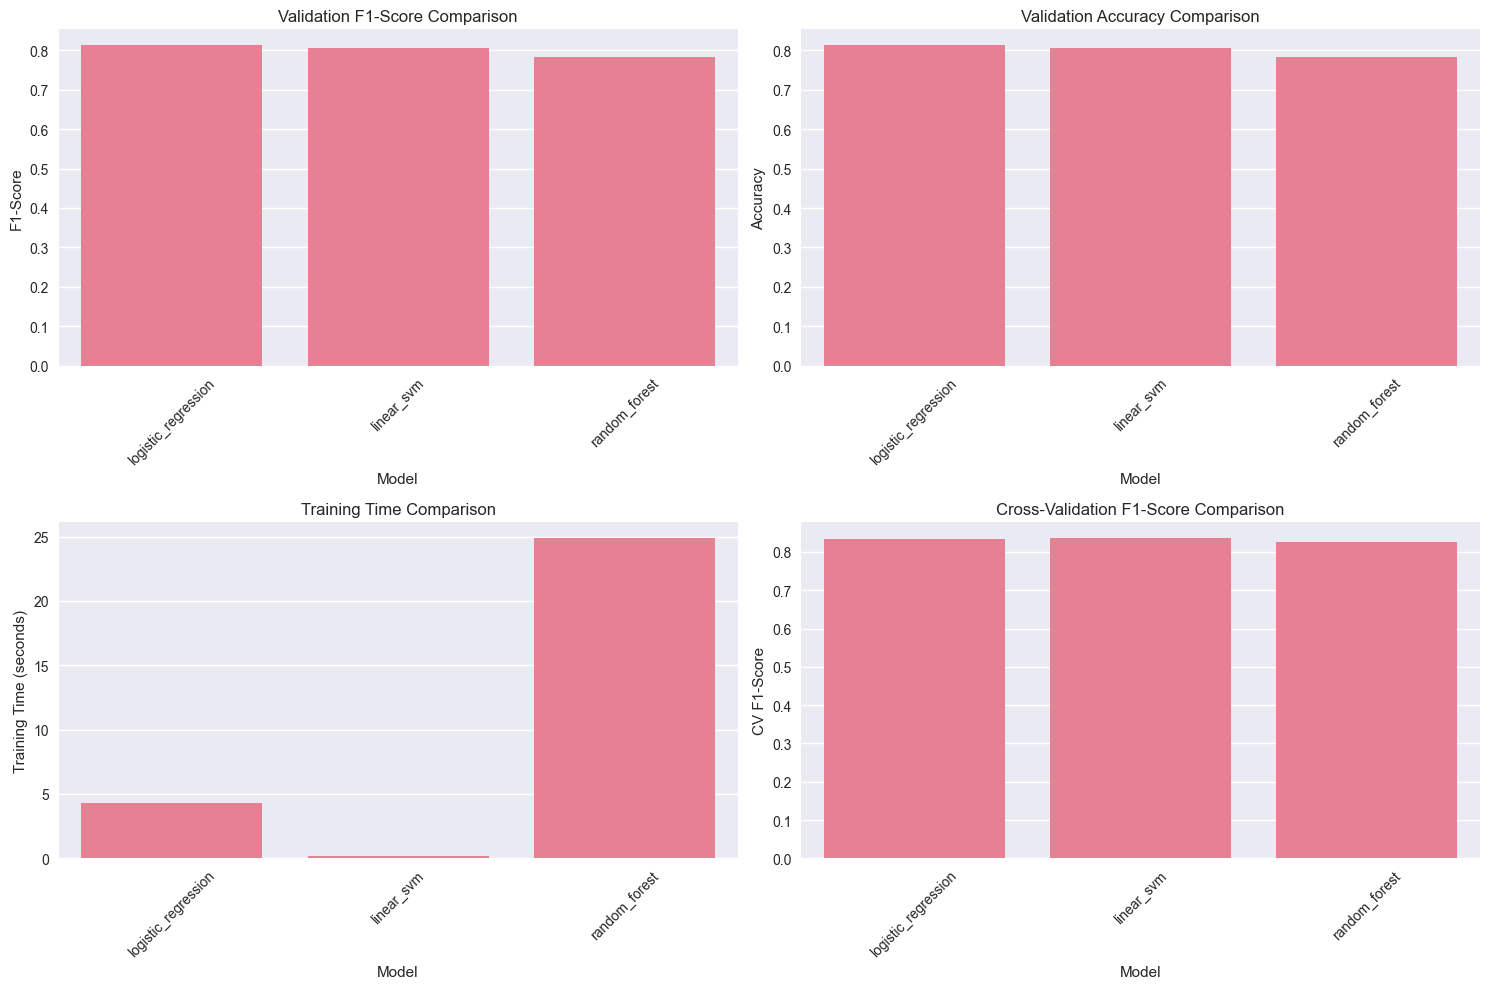

In [20]:
# Display model comparison
comparison_df = training_results['comparison']
print("Model Comparison:")
print(comparison_df.round(4))

# Visualize model comparison
plt.figure(figsize=(15, 10))

# F1-score comparison
plt.subplot(2, 2, 1)
sns.barplot(data=comparison_df, x='model', y='val_f1')
plt.title('Validation F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45)

# Accuracy comparison
plt.subplot(2, 2, 2)
sns.barplot(data=comparison_df, x='model', y='val_accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)

# Training time comparison
plt.subplot(2, 2, 3)
sns.barplot(data=comparison_df, x='model', y='training_time')
plt.title('Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=45)

# Cross-validation score comparison
plt.subplot(2, 2, 4)
sns.barplot(data=comparison_df, x='model', y='cv_mean_f1')
plt.title('Cross-Validation F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('CV F1-Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Best Model Analysis

In [21]:
# Analyze the best model
best_model_name = training_results['best_model_name']
best_results = training_results['all_models'][best_model_name]

print(f"=== BEST MODEL ANALYSIS: {best_model_name.upper()} ===")
print(f"\nBest hyperparameters:")
for param, value in best_results['best_params'].items():
    print(f"  {param}: {value}")

print(f"\nCross-validation scores:")
print(f"  Mean F1-score: {best_results['cv_mean']:.4f}")
print(f"  Std F1-score: {best_results['cv_std']:.4f}")
print(f"  All CV scores: {[f'{score:.4f}' for score in best_results['cv_scores']]}")

print(f"\nValidation metrics:")
for metric, value in best_results['val_metrics'].items():
    print(f"  {metric}: {value:.4f}")

print(f"\nTraining metrics:")
for metric, value in best_results['train_metrics'].items():
    print(f"  {metric}: {value:.4f}")

=== BEST MODEL ANALYSIS: LOGISTIC_REGRESSION ===

Best hyperparameters:
  C: 10.0
  penalty: l2
  solver: liblinear

Cross-validation scores:
  Mean F1-score: 0.8336
  Std F1-score: 0.0132
  All CV scores: ['0.8346', '0.8500', '0.8244', '0.8450', '0.8140']

Validation metrics:
  accuracy: 0.8123
  precision: 0.8141
  recall: 0.8123
  f1_score: 0.8120
  roc_auc: 0.8941

Training metrics:
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1_score: 1.0000
  roc_auc: 1.0000


Top 20 Most Important Features:
        feature  importance
3836      great    5.559547
585       awful    4.996700
612         bad    4.604512
9830      worst    4.436056
9576      waste    4.081037
356    annoying    3.901847
9827      worse    3.760465
2813  excellent    3.746905
266        also    3.712763
8801   terrible    3.564715
2723       even    3.445147
6789       poor    3.311388
2187  different    3.044535
1005  brilliant    2.870076
5196       love    2.853267
9648       well    2.728850
8533     stupid    2.688907
301     amazing    2.686447
8862      thing    2.680415
9035      today    2.610221


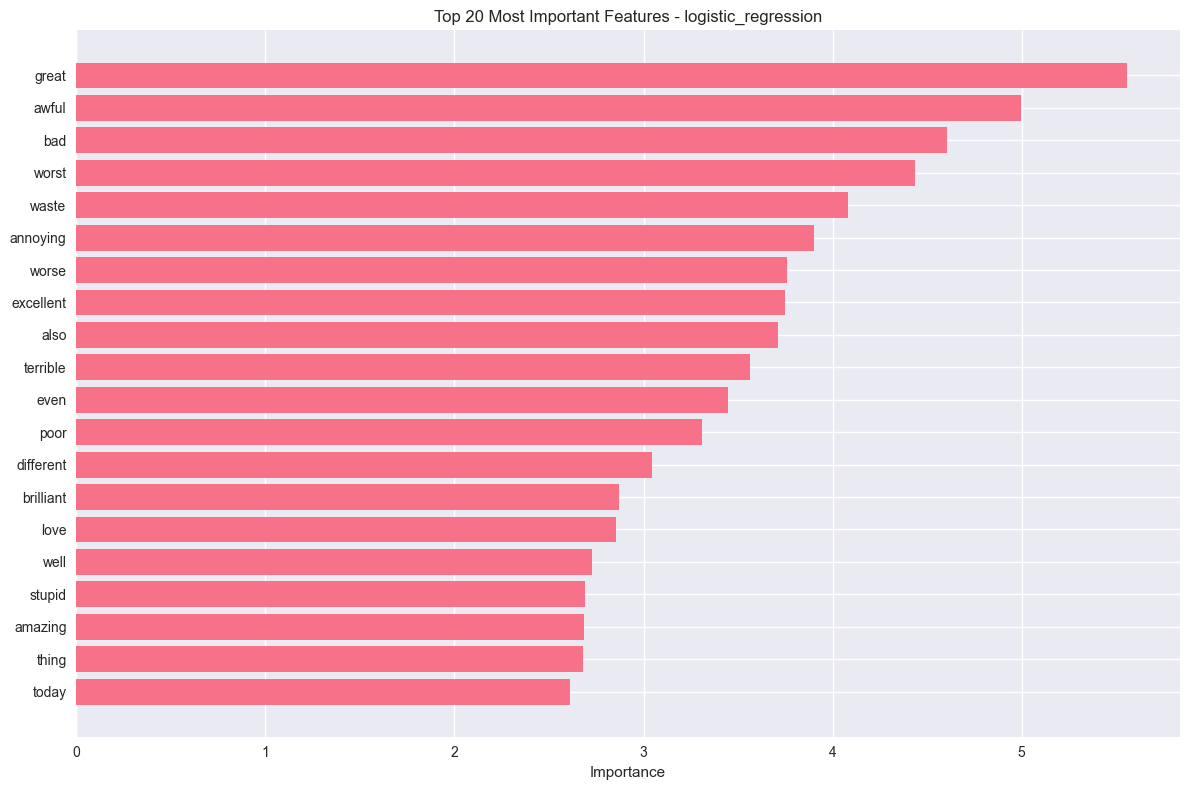

In [22]:
# Feature importance analysis (if available)
feature_importance_df = trainer.get_feature_importance(feature_names)

if feature_importance_df is not None:
    print("Top 20 Most Important Features:")
    print(feature_importance_df.head(20))
    
    # Visualize top features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(20)
    
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.title(f'Top 20 Most Important Features - {best_model_name}')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 5. Model Evaluation on Test Set

INFO:evaluate:Evaluating logistic_regression on test set...


Evaluating logistic_regression on test set...


INFO:utils:Confusion matrix saved to ../plots\logistic_regression_confusion_matrix.png


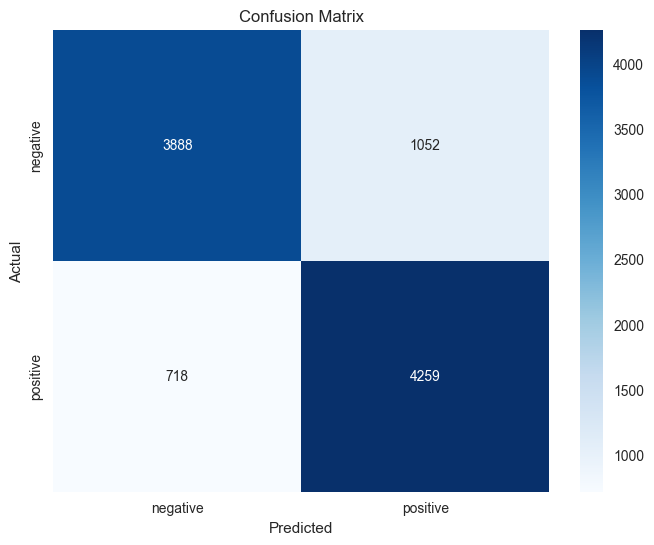

INFO:utils:ROC curve saved to ../plots\logistic_regression_roc_curve.png


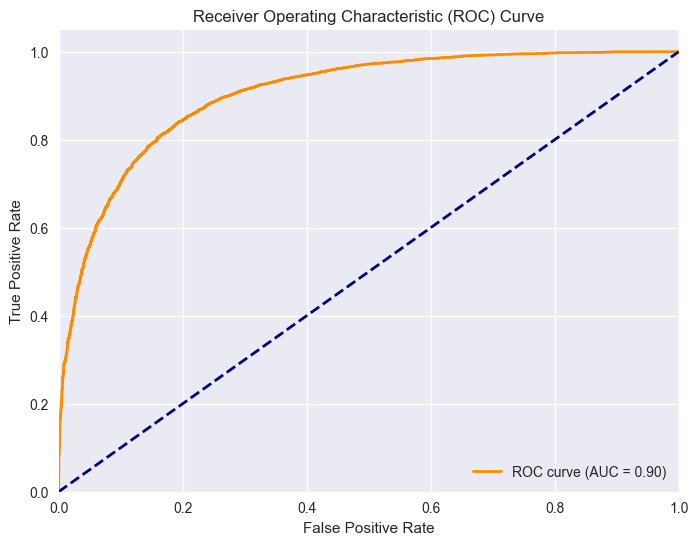

INFO:evaluate:Evaluation completed for logistic_regression
INFO:evaluate:Test Accuracy: 0.8215
INFO:evaluate:Test F1-score: 0.8280
INFO:evaluate:Test ROC-AUC: 0.9040



Test Results for logistic_regression:
  accuracy: 0.8215
  precision_macro: 0.8230
  precision_micro: 0.8215
  precision_weighted: 0.8229
  recall_macro: 0.8214
  recall_micro: 0.8215
  recall_weighted: 0.8215
  f1_macro: 0.8213
  f1_micro: 0.8215
  f1_weighted: 0.8213
  f1_score: 0.8280
  roc_auc: 0.9040
  precision_binary: 0.8019
  recall_binary: 0.8557
  f1_binary: 0.8280


In [23]:
# Initialize evaluator
evaluator = ModelEvaluator()

# Evaluate the best model on test set
print(f"Evaluating {best_model_name} on test set...")
test_results = evaluator.evaluate_model(
    trainer.best_model,
    X_test,
    y_test,
    model_name=best_model_name,
    label_encoder=feature_engineer.label_encoder,
    save_plots=True,
    plot_dir='../plots'
)

print(f"\nTest Results for {best_model_name}:")
for metric, value in test_results['metrics'].items():
    print(f"  {metric}: {value:.4f}")

In [24]:
# Display detailed classification report
print("Detailed Classification Report:")
print(classification_report(
    test_results['true_labels'],
    test_results['predictions'],
    target_names=test_results['class_names']
))

# Display confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(test_results['true_labels'], test_results['predictions'])
print(cm)

if len(test_results['class_names']) == 2:
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix Details:")
    print(f"  True Negatives: {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives: {tp}")
    
    # Calculate additional metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\nAdditional Metrics:")
    print(f"  Precision (Positive): {precision:.4f}")
    print(f"  Recall (Positive): {recall:.4f}")
    print(f"  Specificity (Negative): {specificity:.4f}")

Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.79      0.81      4940
    positive       0.80      0.86      0.83      4977

    accuracy                           0.82      9917
   macro avg       0.82      0.82      0.82      9917
weighted avg       0.82      0.82      0.82      9917

Confusion Matrix:
[[3888 1052]
 [ 718 4259]]

Confusion Matrix Details:
  True Negatives: 3888
  False Positives: 1052
  False Negatives: 718
  True Positives: 4259

Additional Metrics:
  Precision (Positive): 0.8019
  Recall (Positive): 0.8557
  Specificity (Negative): 0.7870


## 6. Error Analysis

In [25]:
# Analyze prediction errors
test_df_analysis = test_df.copy()
test_df_analysis['predicted_sentiment'] = test_results['predictions']
test_df_analysis['prediction_probability'] = test_results['probabilities']
test_df_analysis['true_label_encoded'] = test_results['true_labels']

# Identify misclassified examples
misclassified = test_df_analysis[
    test_df_analysis['sentiment'] != test_df_analysis['predicted_sentiment']
]

print(f"Total test samples: {len(test_df_analysis)}")
print(f"Correctly classified: {len(test_df_analysis) - len(misclassified)}")
print(f"Misclassified: {len(misclassified)}")
print(f"Error rate: {len(misclassified)/len(test_df_analysis)*100:.2f}%")

# Display some misclassified examples
print(f"\n=== MISCLASSIFIED EXAMPLES ===")
for i, (_, row) in enumerate(misclassified.head(5).iterrows()):
    print(f"\nExample {i+1}:")
    print(f"True sentiment: {row['sentiment']}")
    print(f"Predicted sentiment: {row['predicted_sentiment']}")
    print(f"Prediction probability: {row['prediction_probability']:.4f}")
    print(f"Review: {row['review'][:200]}...")
    print("-" * 80)

Total test samples: 9917
Correctly classified: 0
Misclassified: 9917
Error rate: 100.00%

=== MISCLASSIFIED EXAMPLES ===

Example 1:
True sentiment: negative
Predicted sentiment: 0
Prediction probability: 0.0232
Review: My wife and I watched this after DVR'ing it off of Encore action this past week. It has to be the worst horror flick either of us had ever seen. Predictable dialogue ( my wife and I were guessing the ...
--------------------------------------------------------------------------------

Example 2:
True sentiment: positive
Predicted sentiment: 1
Prediction probability: 0.8430
Review: I was surprised how much I enjoyed this. Sure it is a bit slow moving in parts, but what else would one expect from Rollin? Also there is plenty of nudity, nothing wrong with that, particularly as it ...
--------------------------------------------------------------------------------

Example 3:
True sentiment: positive
Predicted sentiment: 1
Prediction probability: 0.7511
Review: Such a delig

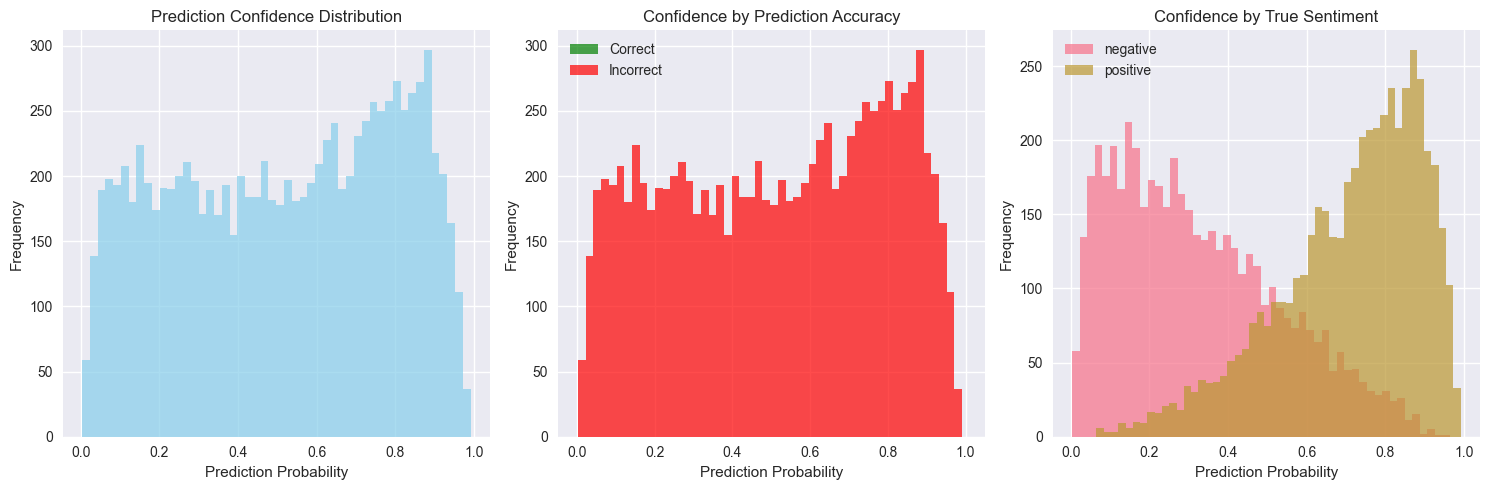

Confidence Statistics:
Overall mean confidence: 0.5170
Correct predictions mean confidence: nan
Incorrect predictions mean confidence: 0.5170


In [26]:
# Analyze confidence distribution
plt.figure(figsize=(15, 5))

# Overall confidence distribution
plt.subplot(1, 3, 1)
plt.hist(test_results['probabilities'], bins=50, alpha=0.7, color='skyblue')
plt.title('Prediction Confidence Distribution')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')

# Confidence for correct predictions
correct_mask = test_df_analysis['sentiment'] == test_df_analysis['predicted_sentiment']
plt.subplot(1, 3, 2)
plt.hist(test_df_analysis[correct_mask]['prediction_probability'], 
         bins=50, alpha=0.7, color='green', label='Correct')
plt.hist(test_df_analysis[~correct_mask]['prediction_probability'], 
         bins=50, alpha=0.7, color='red', label='Incorrect')
plt.title('Confidence by Prediction Accuracy')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

# Confidence by true sentiment
plt.subplot(1, 3, 3)
for sentiment in test_df_analysis['sentiment'].unique():
    sentiment_data = test_df_analysis[test_df_analysis['sentiment'] == sentiment]
    plt.hist(sentiment_data['prediction_probability'], 
             bins=50, alpha=0.7, label=sentiment)
plt.title('Confidence by True Sentiment')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Confidence statistics
print("Confidence Statistics:")
print(f"Overall mean confidence: {np.mean(test_results['probabilities']):.4f}")
print(f"Correct predictions mean confidence: {np.mean(test_df_analysis[correct_mask]['prediction_probability']):.4f}")
print(f"Incorrect predictions mean confidence: {np.mean(test_df_analysis[~correct_mask]['prediction_probability']):.4f}")

## 7. Save Model and Results

## 8. Model Performance Summary

In [ ]:
# Create a comprehensive performance summary
performance_summary = {
    'best_model': {
        'name': best_model_name,
        'hyperparameters': best_results['best_params'],
        'validation_f1': best_results['val_metrics']['f1_score'],
        'test_f1': test_results['metrics']['f1_score'],
        'test_accuracy': test_results['metrics']['accuracy'],
        'test_roc_auc': test_results['metrics'].get('roc_auc', 'N/A')
    },
    'feature_engineering': {
        'vocabulary_size': feature_engineer.get_vocabulary_size(),
        'max_features': feature_engineer.max_features,
        'ngram_range': feature_engineer.ngram_range,
        'preprocessing': {
            'remove_stopwords': feature_engineer.remove_stopwords,
            'use_lemmatization': feature_engineer.use_lemmatization
        }
    },
    'training_info': {
        'total_training_time': training_results['total_training_time'],
        'cross_validation_f1_mean': best_results['cv_mean'],
        'cross_validation_f1_std': best_results['cv_std']
    },
    'data_info': {
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
        'feature_dimensions': X_train.shape[1]
    }
}

print("=== MODEL PERFORMANCE SUMMARY ===")
print(f"\nBest Model: {performance_summary['best_model']['name']}")
print(f"Test Accuracy: {performance_summary['best_model']['test_accuracy']:.4f}")
print(f"Test F1-Score: {performance_summary['best_model']['test_f1']:.4f}")
if performance_summary['best_model']['test_roc_auc'] != 'N/A':
    print(f"Test ROC-AUC: {performance_summary['best_model']['test_roc_auc']:.4f}")

print(f"\nFeature Engineering:")
print(f"  Vocabulary Size: {performance_summary['feature_engineering']['vocabulary_size']}")
print(f"  Feature Dimensions: {performance_summary['data_info']['feature_dimensions']}")
print(f"  Preprocessing: Stopwords removed={performance_summary['feature_engineering']['preprocessing']['remove_stopwords']}, Lemmatization={performance_summary['feature_engineering']['preprocessing']['use_lemmatization']}")

print(f"\nTraining:")
print(f"  Total Time: {format_time(performance_summary['training_info']['total_training_time'])}")
print(f"  CV F1-Score: {performance_summary['training_info']['cross_validation_f1_mean']:.4f} ± {performance_summary['training_info']['cross_validation_f1_std']:.4f}")

print(f"\nData:")
print(f"  Train/Val/Test samples: {performance_summary['data_info']['train_samples']}/{performance_summary['data_info']['val_samples']}/{performance_summary['data_info']['test_samples']}")

print("\n=== CONCLUSION ===")
if performance_summary['best_model']['test_f1'] > 0.85:
    print("✓ Excellent model performance achieved!")
elif performance_summary['best_model']['test_f1'] > 0.80:
    print("✓ Good model performance achieved.")
elif performance_summary['best_model']['test_f1'] > 0.75:
    print("✓ Acceptable model performance.")
else:
    print("⚠ Model performance could be improved.")

print("\nModel is ready for deployment!")

=== MODEL PERFORMANCE SUMMARY ===

Best Model: logistic_regression
Test Accuracy: 0.8215
Test F1-Score: 0.8280
Test ROC-AUC: 0.9040

Feature Engineering:
  Vocabulary Size: 10000
  Feature Dimensions: 10000
  Preprocessing: Stopwords removed=True, Lemmatization=True

Training:
  Total Time: 29.40 seconds
  CV F1-Score: 0.8336 ± 0.0132

Data:
  Train/Val/Test samples: 34706/4959/9917

=== CONCLUSION ===
✓ Good model performance achieved.

Model is ready for deployment!


In [31]:
# Save the best model
model_save_path = '../models/best_model.joblib'
trainer.save_best_model(model_save_path, feature_engineer)
print(f"Best model saved to {model_save_path}")

# Save feature engineering pipeline
feature_pipeline_path = '../models/feature_pipeline.joblib'
feature_engineer.save_pipeline(feature_pipeline_path)
print(f"Feature pipeline saved to {feature_pipeline_path}")

# Save evaluation results
evaluator.save_all_results('../evaluation_results')
print("Evaluation results saved to ../evaluation_results/")

# Generate and save final report
final_report = evaluator.generate_evaluation_report(
    best_model_name, 
    save_path='../evaluation_results/final_report.txt'
)
print("\n=== FINAL EVALUATION REPORT ===")
print(final_report)

INFO:train:Best model saved to ../models/best_model.joblib


Best model saved to ../models/best_model.joblib


INFO:feature_engineering:Pipeline saved to ../models/feature_pipeline.joblib
INFO:utils:Metrics saved to ../evaluation_results\logistic_regression\metrics.json
INFO:utils:Metrics saved to ../evaluation_results\logistic_regression\classification_report.json


Feature pipeline saved to ../models/feature_pipeline.joblib


INFO:evaluate:Evaluation report saved to ../evaluation_results\logistic_regression\evaluation_report.txt
INFO:evaluate:All evaluation results saved to ../evaluation_results
INFO:evaluate:Evaluation report saved to ../evaluation_results/final_report.txt


Evaluation results saved to ../evaluation_results/

=== FINAL EVALUATION REPORT ===
=== EVALUATION REPORT FOR LOGISTIC_REGRESSION ===

OVERALL METRICS:
Accuracy: 0.8215
F1-score (weighted): 0.8213
Precision (weighted): 0.8229
Recall (weighted): 0.8215
ROC-AUC: 0.9040

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    negative       0.84      0.79      0.81      4940
    positive       0.80      0.86      0.83      4977

    accuracy                           0.82      9917
   macro avg       0.82      0.82      0.82      9917
weighted avg       0.82      0.82      0.82      9917

CONFUSION MATRIX ANALYSIS:
True Positives: 4259
True Negatives: 3888
False Positives: 1052
False Negatives: 718

